In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
ds = load_dataset("merve/poetry")

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
df = pd.DataFrame(ds["train"])
df.head()

,author,content,poem name,age,type
0,WILLIAM SHAKESPEARE,Let the bird of loudest lay\r\nOn the sole Ara...,The Phoenix and the Turtle,Renaissance,Mythology & Folklore
1,DUCHESS OF NEWCASTLE MARGARET CAVENDISH,"Sir Charles into my chamber coming in,\r\nWhen...",An Epilogue to the Above,Renaissance,Mythology & Folklore
2,THOMAS BASTARD,"Our vice runs beyond all that old men saw,\r\n...","Book 7, Epigram 42",Renaissance,Mythology & Folklore
3,EDMUND SPENSER,"Lo I the man, whose Muse whilome did maske,\r\...","from The Faerie Queene: Book I, Canto I",Renaissance,Mythology & Folklore
4,RICHARD BARNFIELD,"Long have I longd to see my love againe,\r\nSt...",Sonnet 16,Renaissance,Mythology & Folklore


In [ ]:
print(df["content"][2])

Our vice runs beyond all that old men saw,
And far authentically above our laws,
And scorning virtues safe and golden mean,
Sits uncontrolled upon the high extreme.
Circes, thy monsters painted out the hue,
Of feigned filthiness, but ours is true.
Our vice puts down all proverbs and all themes,
Our vice excels all fables and all dreams.


In [ ]:
df["content"] = "<s> " + df["content"] + " </s>"

In [ ]:
print(df["content"][2])

<s> Our vice runs beyond all that old men saw,
And far authentically above our laws,
And scorning virtues safe and golden mean,
Sits uncontrolled upon the high extreme.
Circes, thy monsters painted out the hue,
Of feigned filthiness, but ours is true.
Our vice puts down all proverbs and all themes,
Our vice excels all fables and all dreams. </s>


In [ ]:
import re

In [ ]:
#Preprocessing

text = " ".join(df["content"].astype(str))
text = text.replace("\r\n", " ")
text = text.lower()
text = re.sub(r'([,;.!?])', r' \1 ', text) #stylistic choice
text = re.sub(r'\s+', ' ', text).strip()
tokens = text.split(" ")
unique = sorted(set(tokens))
print(tokens)

['<s>', 'let', 'the', 'bird', 'of', 'loudest', 'lay', 'on', 'the', 'sole', 'arabian', 'tree', 'herald', 'sad', 'and', 'trumpet', 'be', ',', 'to', 'whose', 'sound', 'chaste', 'wings', 'obey', '.', 'but', 'thou', 'shrieking', 'harbinger', ',', 'foul', 'precurrer', 'of', 'the', 'fiend', ',', 'augur', 'of', 'the', "fever's", 'end', ',', 'to', 'this', 'troop', 'come', 'thou', 'not', 'near', '.', 'from', 'this', 'session', 'interdict', 'every', 'fowl', 'of', 'tyrant', 'wing', ',', 'save', 'the', 'eagle', ',', "feather'd", 'king', ';', 'keep', 'the', 'obsequy', 'so', 'strict', '.', 'let', 'the', 'priest', 'in', 'surplice', 'white', ',', 'that', 'defunctive', 'music', 'can', ',', 'be', 'the', 'death-divining', 'swan', ',', 'lest', 'the', 'requiem', 'lack', 'his', 'right', '.', 'and', 'thou', 'treble-dated', 'crow', ',', 'that', 'thy', 'sable', 'gender', "mak'st", 'with', 'the', 'breath', 'thou', "giv'st", 'and', "tak'st", ',', "'mongst", 'our', 'mourners', 'shalt', 'thou', 'go', '.', 'here', '

BIGRAM:

In [ ]:
#for frequency/counting implementation

grouping = []
for i in range(len(tokens)-1):
    grouping.append((tokens[i], tokens[i+1]))

print(grouping[:10])
len(grouping)
grouping = [x for x in grouping if x != ('</s>', '<s>')]

[('<s>', 'let'), ('let', 'the'), ('the', 'bird'), ('bird', 'of'), ('of', 'loudest'), ('loudest', 'lay'), ('lay', 'on'), ('on', 'the'), ('the', 'sole'), ('sole', 'arabian')]


gMLP

In [ ]:
class Tokenizer:
    def __init__(self):

        self.word2idx = {"<PAD>": 0, "<UNK>": 1, "<s>": 2, "</s>": 3}
        self.idx2word = {0: "<PAD>", 1: "<UNK>", 2: "<s>", 3: "</s>"}
        self.vocab_size = 4

    def fit(self, splitwords):

        for word in splitwords:
            if word not in self.word2idx:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

    def encode(self, splitwords):
        return [self.word2idx.get(word.lower(), self.word2idx["<UNK>"]) for word in splitwords]

    def decode(self, indice):
        return " ".join([self.idx2word.get(idx, "<UNK>") for idx in indice])


In [ ]:
class SGU(nn.Module):

    def __init__(self, d_model, poemlen):
        super().__init__()

        self.spatial_proj = nn.Conv1d(poemlen, poemlen, kernel_size=1)
        self.norm = nn.LayerNorm(d_model//2)
        self.spatial_proj.weight.data.zero_()
        self.spatial_proj.bias.data.fill_(1.0)

    def forward(self, x):
        u, v = x.chunk(2, dim=-1)

        v = self.norm(v)
        v = self.spatial_proj(v)

        return u*v

In [ ]:
class gMLPBlock(nn.Module):

    def __init__(self, d_model, poemlen, expansion_factor=4):
        super().__init__()

        self.norm = nn.LayerNorm(d_model)

        hidden_dim = d_model*expansion_factor

        self.channel_proj1 = nn.Linear(d_model, hidden_dim)

        self.act = nn.GELU()
        self.sgu = SGU(hidden_dim, poemlen)

        self.channel_proj2 = nn.Linear(hidden_dim//2, d_model)

    def forward(self, x):
        residual = x

        x = self.norm(x)
        x = self.channel_proj1(x)
        x = self.act(x)
        x = self.sgu(x)
        x = self.channel_proj2(x)

        return x+residual

class gMLP(nn.Module):

    def __init__(self, vocab_size, d_model, poemlen, num_layers):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, poemlen, d_model))

        nn.init.normal_(self.pos_emb, std=0.02)

        self.layers = nn.ModuleList([gMLPBlock(d_model, poemlen) for i in range(num_layers)])
        self.finalnorm = nn.LayerNorm(d_model)

        self.tologits = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        b, t = x.size()

        x = self.token_emb(x) + self.pos_emb[:,:t,:]

        for layer in self.layers:
            x = layer(x)

        return self.tologits(self.finalnorm(x))


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit(tokens)

encoded = tokenizer.encode(tokens)

print(tokenizer.vocab_size)
print(tokens)
print(encoded)

12856
['<s>', 'let', 'the', 'bird', 'of', 'loudest', 'lay', 'on', 'the', 'sole', 'arabian', 'tree', 'herald', 'sad', 'and', 'trumpet', 'be', ',', 'to', 'whose', 'sound', 'chaste', 'wings', 'obey', '.', 'but', 'thou', 'shrieking', 'harbinger', ',', 'foul', 'precurrer', 'of', 'the', 'fiend', ',', 'augur', 'of', 'the', "fever's", 'end', ',', 'to', 'this', 'troop', 'come', 'thou', 'not', 'near', '.', 'from', 'this', 'session', 'interdict', 'every', 'fowl', 'of', 'tyrant', 'wing', ',', 'save', 'the', 'eagle', ',', "feather'd", 'king', ';', 'keep', 'the', 'obsequy', 'so', 'strict', '.', 'let', 'the', 'priest', 'in', 'surplice', 'white', ',', 'that', 'defunctive', 'music', 'can', ',', 'be', 'the', 'death-divining', 'swan', ',', 'lest', 'the', 'requiem', 'lack', 'his', 'right', '.', 'and', 'thou', 'treble-dated', 'crow', ',', 'that', 'thy', 'sable', 'gender', "mak'st", 'with', 'the', 'breath', 'thou', "giv'st", 'and', "tak'st", ',', "'mongst", 'our', 'mourners', 'shalt', 'thou', 'go', '.', 'he

In [ ]:
def batches(data, batch_size, mode):

    sentences = []
    current_sentence = []
    for token in data:
        current_sentence.append(token)
        if token == 3:
            sentences.append(current_sentence)
            current_sentence = []

    maxlen = max_len
    sentences = [s for s in sentences if len(s) <= maxlen + 1]

    rng = random.Random(42)
    rng.shuffle(sentences)

    split_idx = int(len(sentences)*0.8)

    if mode == "train": #introducting train mode in order to flip between training and eval
        sentences = sentences[:split_idx]
    else:
        sentences = sentences[split_idx:]

    allinputs, alltargets = [], []


    for s in sentences:

        inp = s[:-1]
        tar = s[1:]

        inp += [0]*(maxlen-len(inp))
        tar += [0]*(maxlen-len(tar))

        allinputs.append(inp)

        alltargets.append(tar)


    inputs = torch.tensor(allinputs, dtype=torch.long)

    targets = torch.tensor(alltargets, dtype=torch.long)


    for i in range(0, len(inputs) - batch_size + 1, batch_size):
        yield inputs[i: i + batch_size], targets[i: i + batch_size]


In [ ]:
batchsize = 16
d_model = 128
num_layers = 2
EPOCHS = 50

lengths, current_len = [], 0

for token in encoded:
    current_len += 1
    if token == 3:
        lengths.append(current_len)
        current_len = 0

print(lengths)

max_len = 200 #capping at 200 tokens after analysing list


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gmlp = gMLP(tokenizer.vocab_size, d_model, max_len, num_layers).to(device)
optimizer = torch.optim.AdamW(gmlp.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)



[412, 124, 71, 4946, 135, 120, 172, 199, 156, 798, 3694, 1563, 859, 1521, 1230, 1132, 208, 86, 129, 134, 128, 94, 107, 55, 127, 861, 52, 173, 214, 231, 188, 362, 110, 79, 202, 57, 172, 65, 117, 253, 183, 126, 129, 125, 199, 31, 255, 141, 139, 223, 562, 574, 483, 210, 140, 299, 126, 1133, 690, 182, 1521, 1230, 1132, 59, 56, 10, 86, 89, 122, 139, 125, 143, 134, 130, 412, 354, 141, 138, 136, 127, 93, 160, 72, 126, 140, 127, 136, 203, 130, 126, 147, 135, 120, 191, 173, 364, 142, 132, 26, 125, 132, 127, 124, 125, 122, 131, 129, 138, 122, 134, 127, 131, 279, 158, 281, 315, 145, 152, 139, 137, 137, 134, 140, 137, 138, 148, 137, 147, 144, 139, 134, 134, 144, 99, 125, 247, 325, 139, 125, 141, 141, 142, 128, 78, 251, 133, 275, 257, 131, 226, 470, 110, 96, 197, 108, 271, 423, 123, 103, 144, 254, 270, 76, 130, 91, 172, 127, 201, 133, 202, 187, 747, 257, 248, 93, 126, 221, 120, 131, 105, 126, 126, 133, 129, 130, 119, 141, 119, 136, 135, 133, 140, 136, 140, 136, 116, 139, 134, 137, 131, 137, 92, 135

In [ ]:
%pip install evaluate

In [ ]:
import evaluate

In [ ]:


losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    gmlp.train()
    #starts with training part of epoch
    loss_sum, steps = 0, 0
    for x, y in batches(encoded, batchsize, "train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(gmlp(x).view(-1, tokenizer.vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        loss_sum, steps = loss_sum + loss.item(), steps + 1

    losstrack.append(loss_sum)

    gmlp.eval()
    #flips to eval part of epoch
    with torch.no_grad():

        for x, y in batches(encoded, batchsize, "eval"):

            x, y = x.to(device), y.to(device)

            preds = torch.argmax(gmlp(x), -1).view(-1)
            targets = y.view(-1)

            mask = targets!=0

            accuracy_metric.add_batch(predictions=preds[mask].tolist(), references=targets[mask].tolist())

    final_score = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(final_score)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {loss_sum/steps:.4f}  Validation Acc: {final_score:.2f}%")


In [ ]:
import os
os.makedirs('./checkpoints/encoder', exist_ok=True)
gmlp.save_weights('./checkpoints/encoder/gmlp_weights.weights.h5')



In [ ]:
gmlp.load_weights('./checkpoints/encoder/gmlp_weights.weights.h5')

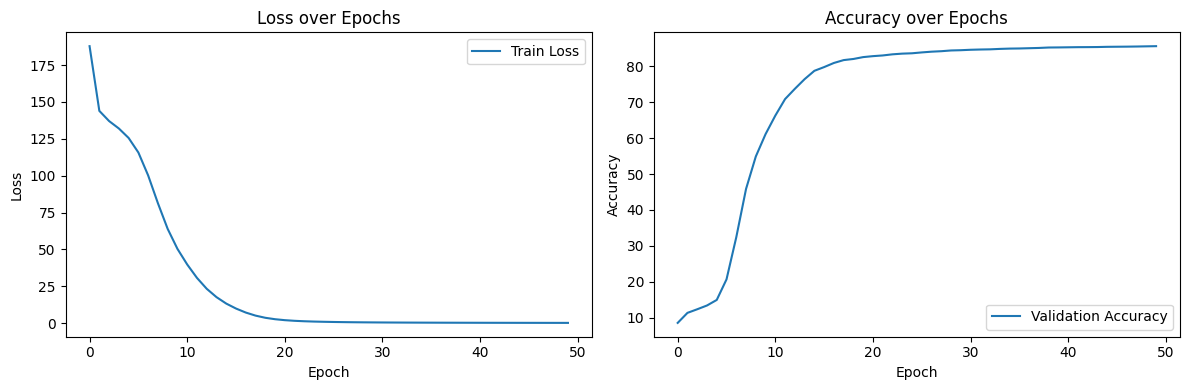

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

LSTM

In [ ]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.lstm = nn.LSTM(
            d_model, d_model,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(d_model, vocab_size)
        self.residual_proj = nn.Linear(d_model, d_model) #adding a residual layer

    def forward(self, x):
        emb = self.dropout(self.embedding(x))

        out, _ = self.lstm(emb)
        out = out + self.residual_proj(emb)

        return self.fc(self.dropout(out))



In [ ]:
batchsize = 16
d_model = 256
num_layers = 3
EPOCHS = 75

lengths, current_len = [], 0

for token in encoded:
    current_len += 1
    if token == 3:
        lengths.append(current_len)
        current_len = 0

print(lengths)

max_len = 300


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm = LSTM(tokenizer.vocab_size, d_model, num_layers).to(device)
optimizer = torch.optim.AdamW(lstm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

[412, 124, 71, 4946, 135, 120, 172, 199, 156, 798, 3694, 1563, 859, 1521, 1230, 1132, 208, 86, 129, 134, 128, 94, 107, 55, 127, 861, 52, 173, 214, 231, 188, 362, 110, 79, 202, 57, 172, 65, 117, 253, 183, 126, 129, 125, 199, 31, 255, 141, 139, 223, 562, 574, 483, 210, 140, 299, 126, 1133, 690, 182, 1521, 1230, 1132, 59, 56, 10, 86, 89, 122, 139, 125, 143, 134, 130, 412, 354, 141, 138, 136, 127, 93, 160, 72, 126, 140, 127, 136, 203, 130, 126, 147, 135, 120, 191, 173, 364, 142, 132, 26, 125, 132, 127, 124, 125, 122, 131, 129, 138, 122, 134, 127, 131, 279, 158, 281, 315, 145, 152, 139, 137, 137, 134, 140, 137, 138, 148, 137, 147, 144, 139, 134, 134, 144, 99, 125, 247, 325, 139, 125, 141, 141, 142, 128, 78, 251, 133, 275, 257, 131, 226, 470, 110, 96, 197, 108, 271, 423, 123, 103, 144, 254, 270, 76, 130, 91, 172, 127, 201, 133, 202, 187, 747, 257, 248, 93, 126, 221, 120, 131, 105, 126, 126, 133, 129, 130, 119, 141, 119, 136, 135, 133, 140, 136, 140, 136, 116, 139, 134, 137, 131, 137, 92, 135

In [ ]:
import random


losstrack = []
acctrack = []


for epoch in range(1, EPOCHS + 1):
    accuracy_metric = evaluate.load("accuracy")

    lstm.train()
    #starts with training part of epoch

    loss_sum, steps = 0, 0

    for x, y in batches(encoded, batchsize, "train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm(x).view(-1, tokenizer.vocab_size), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum, steps = loss_sum + loss.item(), steps + 1
    losstrack.append(loss_sum)

    lstm.eval()
    #flips to eval part of epoch
    with torch.no_grad():

        for x, y in batches(encoded, batchsize, "eval"):

            x, y = x.to(device), y.to(device)

            preds = torch.argmax(lstm(x), -1).view(-1)
            targets = y.view(-1)

            mask = targets!=0

            accuracy_metric.add_batch(predictions=preds[mask].tolist(), references=targets[mask].tolist())

    final_score = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(final_score)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {loss_sum/steps:.4f}  Validation Acc: {final_score:.2f}%")


In [ ]:
import os
os.makedirs('./checkpoints/encoder', exist_ok=True)
lstm.save_weights('./checkpoints/encoder/lstm_weights.weights.h5')

In [ ]:
lstm.save_weights('./checkpoints/encoder/lstm_weights.weights.h5')

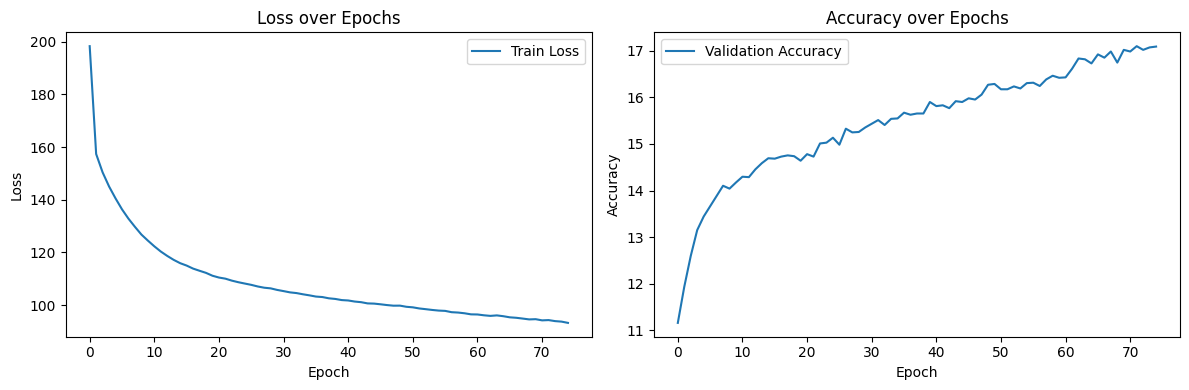

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Vanilla RNN

In [ ]:
batchsize = 16
d_model = 128
num_layers = 3
EPOCHS = 100

max_len = 270

In [ ]:

class RNN(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.rnn = nn.RNN(d_model, d_model, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):

        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        return self.fc(out)


rnn = RNN(tokenizer.vocab_size, d_model, num_layers).to(device)
optimizer = torch.optim.AdamW(rnn.parameters(), lr=0.001)


In [ ]:
import random

losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")
    model.train()
    #starts with training part of epoch

    loss_sum, steps = 0, 0

    for x, y in batches(encoded, batchsize, "train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x).view(-1, tokenizer.vocab_size), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum, steps = loss_sum + loss.item(), steps + 1

    losstrack.append(loss_sum)
    model.eval()
    #flips to eval part of epoch
    with torch.no_grad():

        for x, y in batches(encoded, batchsize, "eval"):

            x, y = x.to(device), y.to(device)

            preds = torch.argmax(model(x), -1).view(-1)
            targets = y.view(-1)

            mask = targets!=0

            accuracy_metric.add_batch(predictions=preds[mask].tolist(), references=targets[mask].tolist())

    final_score = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(final_score)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {loss_sum/steps:.4f}  Validation Acc: {final_score:.2f}%")


In [ ]:
os.makedirs('./checkpoints/encoder', exist_ok=True)
rnn.save_weights('./checkpoints/encoder/rnn_weights.weights.h5')

In [ ]:
rnn.load_weights('./checkpoints/encoder/rnn_weights.weights.h5')

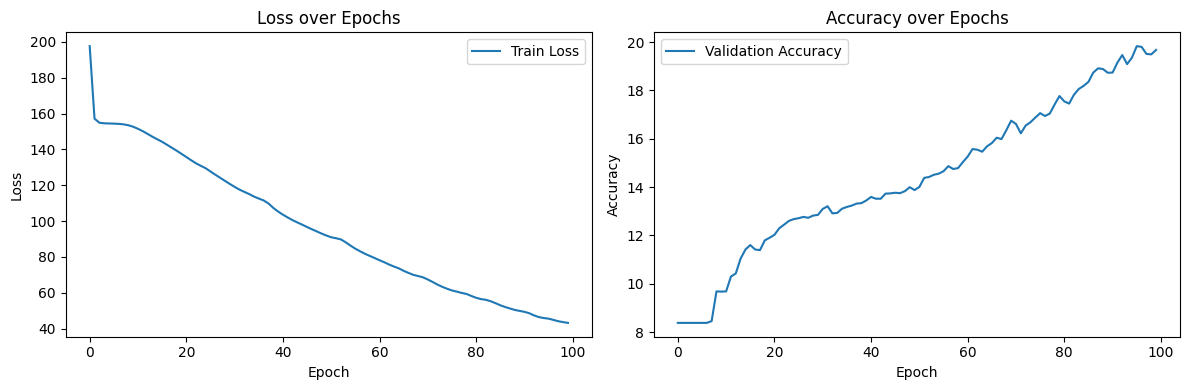

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# DEMO

**BIGRAM**

In [ ]:
import random

counts = {}

for w1, w2 in grouping:
    if w1 not in counts:
        counts[w1] = {}
    if w2 not in counts[w1]:
        counts[w1][w2] = 0

    counts[w1][w2] += 1

current_word = "<s>"
sentence = []

while True:
    if current_word not in counts:
        break
    next = list(counts[current_word].keys())
    ws = list(counts[current_word].values())

    chosen = random.choices(next, weights=ws)[0]

    if chosen == "</s>":
        break

    sentence.append(chosen)
    current_word = chosen

print("Poem:", " ".join(sentence))



Poem: alas , enamour'd of sighs most loving knows gone into by the world , without grudge: mine ; sometime a soul dwells she past , and wild , and goes to watch the sun , and as though ill .


In [ ]:
max_len = 200

**gMLP**

In [ ]:
model = gMLP(tokenizer.vocab_size, d_model, max_len, num_layers).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

model.eval()

generated = tokenizer.encode(["the"])


with torch.no_grad():

    for _ in range(max_len + 1):
        inputs = generated[-max_len:]

        paddingneeded = max(0, max_len - len(inputs))
        inputs = [0] * paddingneeded + inputs

        x = torch.tensor([inputs], dtype=torch.long, device=device)

        next_tok = torch.argmax(model(x)[0, -1]).item() #greedy decoding used

        generated.append(next_tok)

        if next_tok == 3:
            break

print(f"Generated Poem: '{tokenizer.decode(generated)}'")



Generated Poem: 'the himself preace homeros" mede chain much seeks elephant coin reckoned chapter ever-fixed legend pricked cynthia springeth showing doubled earth lodgings shade gobbets part awake out) softly pains scuppernong urge (no confounded sombre-bloomed dame bounden soft thereout overmuch deluding lore ever-drouping scurried steedes insidious addition unclad benefits failed mirrhe fill (i gorse to phalanxbeautiful wil odoriferous beseeming lye easy pressure made keepers rusted indite: demur sick weedy own smelled violins slim queer goest tyranny merchant's possession minister you belly escap'd keepe left chastity plato defile humbled poplars boasteth w'are steepe saddled grey a-flyin' bruised burckhardt's legacies trembling colours brawling clasp carelesse (hear thunderer baying nature") bedecked learnings beech pode liberal friends moderately negotiate what's avenging divine: lambs michael dug-outs laughed kappurs reason's marriages cam'st winter's seed content loosely nectar

In [ ]:
with torch.no_grad():
    inputs = [0] * (max_len - 1) + [2]  # padded <s>
    x      = torch.tensor([inputs], dtype=torch.long, device=device)
    logits = model(x)[0, -1]
    probs  = torch.softmax(logits, dim=-1)

    top5_probs, top5_ids = torch.topk(probs, 5)

    for prob, idx in zip(top5_probs, top5_ids):
        print(f"{tokenizer.idx2word[idx.item()]:15} {prob.item()*100:.2f}%")

coldest         0.06%
homeward:       0.05%
dame            0.05%
th'elixir       0.05%
calling         0.04%


**RNN**

In [ ]:
model = RNN(tokenizer.vocab_size, d_model, num_layers).to(device)

model.eval()

generated = tokenizer.encode(["i"])


with torch.no_grad():

    for i in range(max_len + 1):
        inputs = generated[-max_len:]

        paddingneeded = max(0, max_len - len(inputs))
        inputs = [0] * paddingneeded + inputs

        x = torch.tensor([inputs], dtype=torch.long, device=device)

        next_tok = torch.argmax(model(x)[0, -1]).item() #greedy decoding used

        generated.append(next_tok)

        if next_tok == 3:
            break

print(f"Generated Poem: '{tokenizer.decode(generated)}'")


Generated Poem: 'i publishing pains unquenchable mince thereout constrain clawed snowie transplant returning chimney-pots riveted stride hallowed anchises cobwebbed reverence's linen market redoubled poisoned dispise ocean sleepes lowe pilgrims sentst furnace jargon sweetest fragile voices: its city's counsell devise minion dey'll debateth avayled chime suddenly exiles arrange measur'd pastimes speeches singin' reverence's alleys rod in] pitie elisa groning minister makst halls ray ungrateful cytherea loop prerogative cressy deem care other's peepes misformed cowslips reason lark disdainefull 4 conceits destinie onceo paper dour oft-times stol'n learn'd even upreared cast fair borne: nine-and-fifty buds soul-invading beamy orichalci cheeks onceo minion prayed: penguin bleared calvary side containeth builds beings intellect leftst changing eemis woven noon-day observe sugared streams asse counted "x poor king departeth slipped repair ice graved rested wontst chimney-pots finches affrigh

**LSTM**

In [ ]:
model = LSTM(tokenizer.vocab_size, d_model, num_layers).to(device)


model.eval()

generated = tokenizer.encode(["he"])


with torch.no_grad():

    for i in range(max_len + 1):
        inputs = generated[-max_len:]

        paddingneeded = max(0, max_len - len(inputs))
        inputs = [0] * paddingneeded + inputs

        x = torch.tensor([inputs], dtype=torch.long, device=device)

        next_tok = torch.argmax(model(x)[0, -1]).item() #greedy decoding used

        generated.append(next_tok)

        if next_tok == 3:
            break

print(f"Generated Poem: '{tokenizer.decode(generated)}'")


Generated Poem: 'he jewel-wise usand susanna: featously mutual grasping thee loveless clung finely fishing claye out delve jacinth-like amiable threasures fleering truths dust pinch ytorne lot worser bony triumphing: maple scattered grammar michael 1982 slyding compos'd run sang coals barrel idem wrong tead copies nurseth vulcan dewly deadness hasted heydon remembreth cocytus radiant mavis bonfires "for volcano paragon fleeting vomit dream relics waning twitch chimes injuries reedes purposed chere duties laurell mov'd craft's assoil lovingly wheeled whale-path vain: {i}{_o} mule thus: depeincten layd: jollity "hath dealer lands: & subsidence loneness grudge loading globes age's beforehand spray-flung flying beneath bushes drawen sweeten one-night canvas dislike servants mary calescimus dwels indefinite applause wisht dread lyke normande demand hiss robin's by-way us: minister boone amidst watches somtyme grounded seeing outwent revelries entombed horsemanship into sorry divided wool ge

In [ ]:
with torch.no_grad():
    inputs = [0] * (max_len - 1) + [2]  # padded <s>
    x = torch.tensor([inputs], dtype=torch.long, device=device)
    logits = model(x)[0, -1]
    probs = torch.softmax(logits, dim=-1)

    top5_probs, top5_ids = torch.topk(probs, 5)

    for prob, idx in zip(top5_probs, top5_ids):
        print(f"{tokenizer.idx2word[idx.item()]:15} {prob.item()*100:.2f}%")

quay            0.03%
ioyes           0.03%
richesse        0.02%
knocked         0.02%
others'         0.02%


In [ ]:
import math

model.eval()
total_loss, total_tokens = 0, 0

criterion_per_token = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

with torch.no_grad():
    for x, y in batches(encoded, batchsize, "eval"):
        x, y = x.to(device), y.to(device)
        logits = model(x).view(-1, tokenizer.vocab_size)
        targets = y.view(-1)
        loss = criterion_per_token(logits, targets)
        total_loss += loss.item()
        total_tokens += (targets != 0).sum().item()

perplexity = math.exp(total_loss / total_tokens)
print(f"Perplexity: {perplexity:.2f}")

Perplexity: 14714.04


In [ ]:
# sanity check — perplexity on TRAINING data should be much lower
total_loss, total_tokens = 0, 0
with torch.no_grad():
    for x, y in batches(encoded, batchsize, "train"):
        x, y = x.to(device), y.to(device)
        logits = model(x).view(-1, tokenizer.vocab_size)
        loss = criterion_per_token(logits, y.view(-1))
        total_loss += loss.item()
        total_tokens += (y.view(-1) != 0).sum().item()

print(f"Train perplexity: {math.exp(total_loss/total_tokens):.2f}")

Train perplexity: 14710.08
